In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
from functools import partial
import joblib

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch

import optuna
import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
representation_type = "traditional_word_TF-IDF"

developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "traditional"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"


Connect to databricks for logging results

In [6]:
load_dotenv(env_path)

w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2025/12/13 21:07:15 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.1. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2025/12/13 21:07:15 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/13 21:07:15 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2025/12/13 21:07:15 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/12/13 21:07:15 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


What are GPU are the experiments run on

In [7]:
!nvidia-smi

Sat Dec 13 21:07:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:A3:00.0 Off |                    0 |
|  0%   34C    P8             34W /  300W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
running_on_gpu = torch.cuda.is_available()

In [9]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [10]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

89

In [11]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification threshold constant specification

In [12]:
classification_thresholds = [x/1000 for x in range(200, 999)]

TF-IDF parameters for tuning

In [13]:
max_features = [20_000, 50_000, 100_000, None]
lowercase = [False, True]
sublinear_tf = [True, False]
min_df = (1e-5, 0.01)

# Load dataset

#### Load training data

In [14]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.3G/11.3G [00:23<00:00, 473MB/s]


Successfully loaded 273301 items.


In [15]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [16]:
train_data_df.head(10)

,id,pair,same
0,e05b9c0b-88a1-5608-b7e8-ab1fc6b78dc1,"[Well, ever since you and Kurt broke up youve ...",False
1,12f73a20-cdf3-58df-b5bb-9392eec9b486,"[The thing is, Ryouga has no reason to run aft...",False
2,d82c6764-451b-544c-8711-c139e9349c56,"[Ehhhh nah, its silly' Its my job to listen to...",True
3,876b8380-9260-5427-93e8-dc31155c3edd,"[Glaring at the arrogant spark, Always asks va...",False
4,357e8471-35b9-50b4-9ac0-286ac0e8b101,[Runa limped across the small space to an open...,False
5,6b39fe22-409f-5329-9fe1-ddf4a70bedd1,"[And thats retired Commander, if you please St...",False
6,76ed2017-0c9f-580f-83b1-5a041a8169ec,[Meet you downstairs in twenty minutes I say w...,True
7,fd8deb2e-06de-5c92-9a4c-927891c53657,"[Since Ive seen so many others do so, Im going...",False
8,3ce5e811-a57c-5fbf-9f9a-2ee636e50be6,[party Eishi exclaimed Omi shook his head and ...,False
9,25a17cd2-6b01-5fba-99ef-e631e56e181d,[After a few moments she found that Red was ri...,False


#### Load validation data

In [17]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 103M/103M [00:00<00:00, 563MB/s] 


Successfully loaded 2500 items.


In [18]:
val_data_df = pd.DataFrame(val_data)

#### Load testing data

In [19]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:01<00:00, 502MB/s] 


Successfully loaded 19999 items.


In [20]:
test_data_df = pd.DataFrame(test_data)

# Extract features functions

In [21]:
def build_tfidf_vectorizer(max_features, min_df, lowercase=True, sublinear_tf=True):
    return TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 1),
        max_features=max_features,
        min_df=min_df,
        lowercase=lowercase,
        sublinear_tf=sublinear_tf
    )

# Evaluation functions

Evaluation function

In [22]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average, zero_division=0)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Create the confusion matrix

In [23]:
def plot_confusion_matrix(y_true, y_pred, model_id="", labels=[False, True]):

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')

    plt.tight_layout()
    return fig

Create histogram of F1 score for different thresholds

In [24]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

# Cosine similarity of embeddings functions

Evaluate model function

In [25]:
def compute_similarities(train_df, test_df, vectorizer):
    start_time = time.time()
    verification_results = []

    def extract_all_texts(train_df):
        texts = []
        for pair in tqdm(train_df["pair"], desc="Extracting texts"):
            texts.extend(pair)
        return texts
    
    all_texts = extract_all_texts(train_df)
    print("Fitting texts to the vectorizer")
    vectorizer.fit(all_texts)
    
    for i in tqdm(test_data_df.index, desc="Processing rows"):
        resulting_df_row = {}
        resulting_df_row['id']  = test_data_df.loc[i, 'id']
        resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
        text1 = test_data_df.loc[i, 'pair'][0]
        text2 = test_data_df.loc[i, 'pair'][1]
        
        text1_embedding = vectorizer.transform([text1])
        text2_embedding = vectorizer.transform([text2])

        
        cosine_similarity_score = cosine_similarity(
            text1_embedding,
            text2_embedding
        )[0, 0]

        resulting_df_row['cosine_similarity'] = cosine_similarity_score
        verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Evaluate classification thresholds

In [26]:
def evaluate_classification_thresholds(result_df, classification_thresholds):
    results = []
    y_embeddings = result_df['cosine_similarity']
    y_true = result_df['actual_result']
    for threshold in classification_thresholds:
        y_pred = (result_df["cosine_similarity"] >= threshold).astype(int)
        accuracy, precision, recall, f1 = evaluate_results(y_true, y_pred)
        results.append({
            "threshold": threshold,
            "accuracy" : accuracy,
            "precision" : precision,
            "recall" : recall,
            "f1" : f1
        })
    return pd.DataFrame(results)

# Optuna study function - for cosine similarity of embeddings

In [27]:
def objective(trial):
    top_f1_trial = -1


    max_feat = trial.suggest_categorical("max_features", max_features)
    m_df = trial.suggest_float("min_df", min_df[0], min_df[1])
    lowerc = trial.suggest_categorical("lowercase", lowercase)
    sub_tf = trial.suggest_categorical("sublinear_tf", sublinear_tf)

    print(f"Starting the optuna trial {trial.number} \n")

    vectorizer = build_tfidf_vectorizer(
        max_features=max_feat,
        min_df=m_df, 
        lowercase=lowerc,
        sublinear_tf=sub_tf)

    print(f"Computing similarities\n")
    result_df = compute_similarities(train_data_df, val_data_df, vectorizer)

    print(f"Evaluating classification thresholds \n")
    threshold_results_df = evaluate_classification_thresholds(result_df, classification_thresholds)

    top_row = threshold_results_df.sort_values("f1", ascending=False).iloc[0]
    top_threshold = top_row["threshold"]
    top_f1 = top_row["f1"]
    top_accuracy = top_row["accuracy"]
    top_precision = top_row["precision"]
    top_recall = top_row["recall"]

    print(f"Logging results \n")
    print(f"Top threshold: {top_threshold}\n")
    print(f"Top f1: {top_f1}\n")
    print(f"Top accuracy: { top_accuracy}\n")
    print(f"Top precision: {top_precision}\n")
    print(f"Top recall: {top_recall}\n")

    print(f"Used hyperparameters \n")
    print(f"max_features: {max_feat}\n")
    print(f"min_df: {m_df}\n")
    print(f"lowercase: {lowerc}\n")
    print(f"sublinear_tf: {sub_tf}\n")

    trial.set_user_attr(
    "results",
        {
        "metrics": {
            "top_threshold": top_threshold,
            "top_f1": top_f1,
            "top_accuracy": top_accuracy,
            "top_precision": top_precision,
            "top_recall": top_recall
        },
        "hyperparameters": {
            "max_features": max_feat,
            "min_df": m_df,
            "lowercase": lowerc,
            "sublinear_tf": sub_tf
            }
        }
    )
    
    return top_f1   

# Evaluate cosine embeddings

cosine embedding constants

In [28]:
classifier = "embedding_cosine_similarity"

Set up the study

In [29]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")

In [30]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-13 21:07:42,680] Using an existing study with name 'authorship_verification_traditional_word_TF-IDF_embedding_cosine_similarity' instead of creating a new one.


In [31]:
study.optimize(objective, n_trials=30)

Computing similarities



Extracting texts: 100%|██████████| 273301/273301 [00:00<00:00, 1681759.53it/s]

Fitting texts to the vectorizer



Processing rows: 100%|██████████| 19999/19999 [01:21<00:00, 246.14it/s]


--- Execution Time: 738.93 seconds ---
Evaluating classification thresholds 

Logging results 

Top threshold: 0.2

Top f1: 70.36

Top accuracy: 67.95

Top precision: 65.45

Top recall: 76.08

Used hyperparameters 

max_features: 20000

min_df: 0.002803319077966763

lowercase: True

sublinear_tf: True



...

Extracting texts: 100%|██████████| 273301/273301 [00:00<00:00, 1089644.86it/s]


Fitting texts to the vectorizer


Processing rows: 100%|██████████| 19999/19999 [01:20<00:00, 247.80it/s]


--- Execution Time: 746.28 seconds ---
Evaluating classification thresholds 

Logging results 

Top threshold: 0.2

Top f1: 70.05

Top accuracy: 68.09

Top precision: 66.0

Top recall: 74.62

Used hyperparameters 

max_features: 20000

min_df: 0.002453633518796814

lowercase: True

sublinear_tf: True



[I 2025-12-14 03:24:21,480] Trial 30 finished with value: 70.05 and parameters: {'max_features': 20000, 'min_df': 0.002453633518796814, 'lowercase': True, 'sublinear_tf': True}. Best is trial 22 with value: 74.7.


Load the trial data

In [32]:
rows = []

for t in study.trials:
    if "results" not in t.user_attrs:
        continue
    
    metrics = t.user_attrs["results"]["metrics"]
    hparams = t.user_attrs["results"]["hyperparameters"]

    row = {
        "trial_number": t.number,
        "top_threshold": metrics["top_threshold"],
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        "max_features" : hparams["max_features"],
        "min_df" : hparams["min_df"],
        "lowercase" : hparams["lowercase"],
        "sublinear_tf" : hparams["sublinear_tf"],
    }

    rows.append(row)

trial_results_df = pd.DataFrame(rows)

In [33]:
trial_results_df.head()

,trial_number,top_threshold,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,lowercase,sublinear_tf
0,1,0.200,70.36,67.95,65.45,76.08,20000.0,0.002803,True,True
1,2,0.200,68.17,69.66,71.70,64.98,50000.0,0.002337,False,True
2,3,0.200,66.60,50.15,50.08,99.41,20000.0,0.006669,False,False
3,4,0.200,66.59,50.16,50.08,99.32,20000.0,0.005159,True,False
4,5,0.237,73.62,69.34,64.60,85.57,100000.0,0.009277,True,True


Load the data from the best trial to variables

In [34]:
best_trial = study.best_trial
best_trial_data = best_trial.user_attrs["results"]

In [35]:
top_threshold = best_trial_data["metrics"]["top_threshold"]
top_max_features = best_trial_data["hyperparameters"]["max_features"]
top_min_df = best_trial_data["hyperparameters"]["min_df"]
top_lowercase = best_trial_data["hyperparameters"]["lowercase"]
top_sublinear_tf = best_trial_data["hyperparameters"]["sublinear_tf"]

# Final testing

In [36]:
best_model_path = current_dir.parent.parent / "data" / "02_models" / f"{developer_initials}_{date_str}_{representation_type}_{classifier}_best_model.pkl"

Reconstruct the best vectorizer

In [37]:
best_vectorizer = build_tfidf_vectorizer(
    max_features=top_max_features,
    min_df=top_min_df,
    lowercase=top_lowercase,
    sublinear_tf=top_sublinear_tf 
    )

Combine validation and training dataset

In [38]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

In [39]:
result_df = compute_similarities(final_train_df, test_data_df, best_vectorizer)
threshold_results_df = evaluate_classification_thresholds(result_df, classification_thresholds)

Extracting texts: 100%|██████████| 275801/275801 [00:00<00:00, 1347469.62it/s]


Fitting texts to the vectorizer


Processing rows: 100%|██████████| 19999/19999 [01:17<00:00, 259.70it/s]


--- Execution Time: 734.69 seconds ---


In [40]:
y_scores = result_df["cosine_similarity"].values

In [41]:
y_pred = (y_scores >= top_threshold).astype(int)
y_true = result_df["actual_result"].astype(int).values

Evaluate the final results

In [42]:
top_accuracy, top_precision, top_recall, top_f1 =  evaluate_results(y_true, y_pred, average='binary')

In [43]:
print(f"Logging results \n")
print(f"Top threshold: {top_threshold}\n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"sublinear_tf: {top_sublinear_tf}\n")

Logging results 

Top threshold: 0.238

Top f1: 74.72

Top accuracy: 71.39

Top precision: 66.93

Top recall: 84.55

Used hyperparameters 

max_features: None

min_df: 0.009825819382767229

lowercase: False

sublinear_tf: True



Dump the model

In [44]:
joblib.dump(best_vectorizer, best_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/JP_20251213_2107_traditional_word_TF-IDF_embedding_cosine_similarity_best_model.pkl']

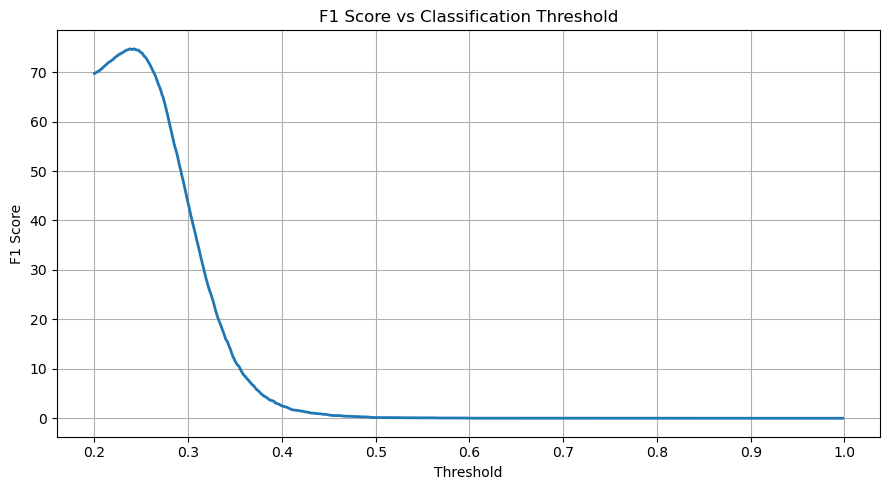

In [45]:
f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)
f1_threshold_histogram_fig.show()

Confusion matrix

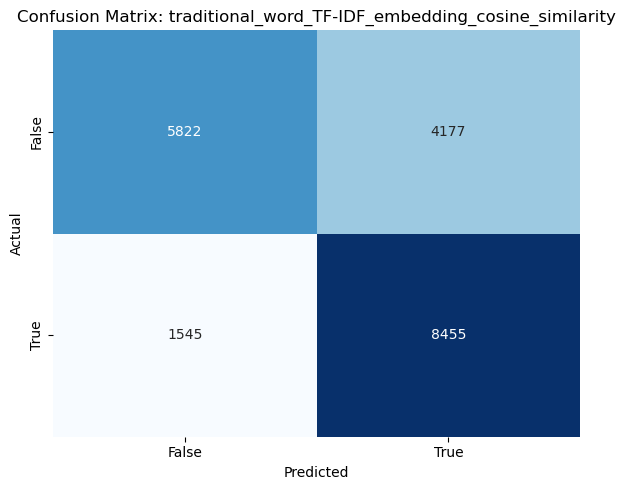

In [46]:
cm_fig = plot_confusion_matrix(y_true, y_pred, f"{representation_type}_{classifier}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [48]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("sublinear_tf", top_sublinear_tf)
    
    mlflow.log_param("classification_score_thresholds", classification_thresholds)
    mlflow.log_table(data=result_df, artifact_file="embedding_similarity_results-test_data.json")

    mlflow.log_metric("top_threshold", top_threshold)
    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(f1_threshold_histogram_fig, "f1_results_threshold_histogram-test_data.png")
    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_TF-IDF_embedding_cosine_similarity at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/01aedafc84734d54a2425ceed366f0ed
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
